# Klasifikasi Citra Kucing dan Anjing
CNN From Scratch dan Transfer Learning MobileNetV2

## Deskripsi Dataset
Dataset yang digunakan adalah Cats and Dogs Dataset


## Import Library

In [138]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Input
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [139]:
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    print("Jumlah file:", len(files))
    print("-"*50)

/kaggle/input
Jumlah file: 0
--------------------------------------------------
/kaggle/input/datasets
Jumlah file: 0
--------------------------------------------------
/kaggle/input/datasets/samuelcortinhas
Jumlah file: 0
--------------------------------------------------
/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification
Jumlah file: 0
--------------------------------------------------
/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/test
Jumlah file: 0
--------------------------------------------------
/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/test/dogs
Jumlah file: 70
--------------------------------------------------
/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/test/cats
Jumlah file: 70
--------------------------------------------------
/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/train
Jumlah file: 0
--------------------------------------------

## Load Dataset

In [140]:
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Training :", x_train.shape)
print("Validation :", x_val.shape)
print("Testing :", x_test.shape)

Training : (40000, 32, 32, 3)
Validation : (10000, 32, 32, 3)
Testing : (10000, 32, 32, 3)


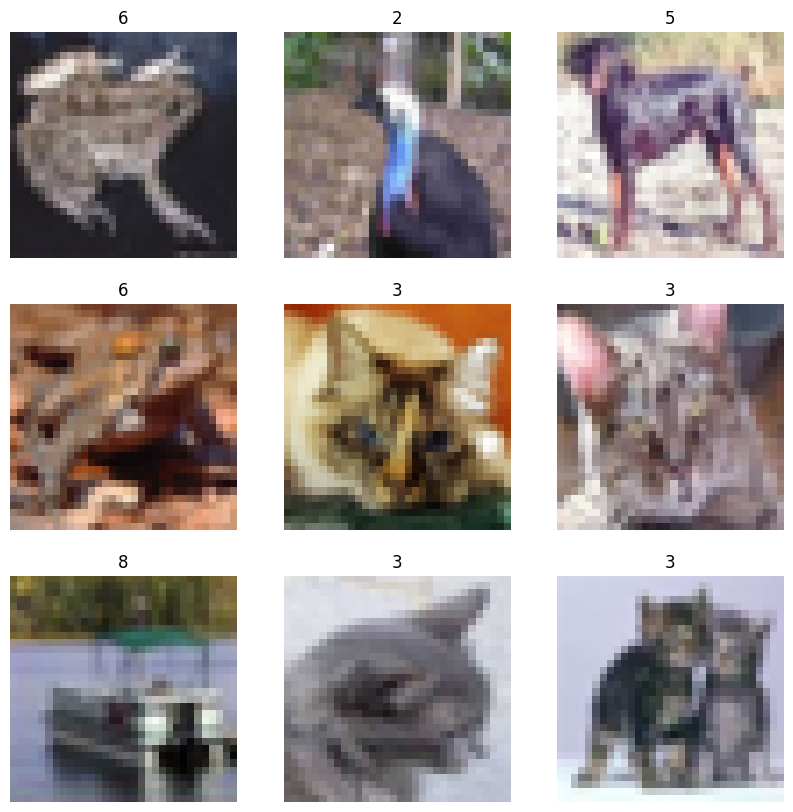

In [141]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(str(y_train[i][0]))
    plt.axis('off')

plt.show()

# A. Eksperimen 1: CNN From Scratch

Mahasiswa membangun model CNN sendiri tanpa menggunakan pretrained model.

## Arsitektur CNN

Model yang digunakan terdiri dari:

1. Convolution Layer
2. Pooling Layer
3. Activation Function (ReLU)
4. Flatten Layer
5. Dense Layer
6. Output Layer

Parameter yang digunakan:

- Jumlah Convolution Layer: 3
- Jumlah Pooling Layer: 3
- Ukuran Filter: 3x3
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- Epoch: 10
- Regularisasi: Dropout (0.5)

In [142]:
cnn_model = Sequential([
    
    Input(shape=(32,32,3)),
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

## Ringkasan Arsitektur CNN

Model CNN yang digunakan terdiri dari:

- 3 Convolution Layer
- 3 MaxPooling Layer
- 1 Flatten Layer
- 1 Dense Layer
- 1 Output Layer
- Fungsi aktivasi ReLU dan Sigmoid

Berikut adalah ringkasan struktur model yang digunakan.

In [143]:
cnn_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

## Training CNN From Scratch

Model CNN dilatih menggunakan optimizer Adam selama 10 epoch dengan batch size 32. Data training digunakan untuk melatih model sedangkan data validation digunakan untuk memantau performa model selama proses pelatihan.

In [144]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [145]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3631 - loss: 1.7204 - val_accuracy: 0.5167 - val_loss: 1.3241
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5236 - loss: 1.3227 - val_accuracy: 0.5890 - val_loss: 1.1621
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5864 - loss: 1.1732 - val_accuracy: 0.6317 - val_loss: 1.0569
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6323 - loss: 1.0648 - val_accuracy: 0.6474 - val_loss: 1.0064
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6589 - loss: 0.9794 - val_accuracy: 0.6699 - val_loss: 0.9312
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6824 - loss: 0.9127 - val_accuracy: 0.6830 - val_loss: 0.9231
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7038 - loss: 0.8597 - val_accuracy: 0.6903 - val_loss: 0.8934
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7176 - loss: 0.8137 -

### Training CNN

Model CNN dilatih menggunakan data training CIFAR-10 selama 10 epoch dengan optimizer Adam dan fungsi loss sparse categorical crossentropy. Data validasi digunakan untuk memantau performa model selama proses pelatihan.

## Evaluasi CNN From Scratch

Model CNN diuji menggunakan data testing untuk mengetahui kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

Hasil evaluasi menunjukkan:

- Test Accuracy : 66.43%
- Test Loss : 1.0147

Nilai akurasi testing yang lebih rendah dibandingkan akurasi training menunjukkan adanya indikasi overfitting pada model CNN.

In [146]:
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy :", test_acc_cnn)
print("Test Loss :", test_loss_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7062 - loss: 0.8797
Test Accuracy : 0.7062000036239624
Test Loss : 0.8797298669815063


## Visualisasi Accuracy dan Loss

Hasil evaluasi menunjukkan nilai accuracy dan loss pada data testing. Nilai ini digunakan untuk mengukur kemampuan model dalam melakukan generalisasi terhadap data baru yang tidak digunakan selama proses pelatihan.

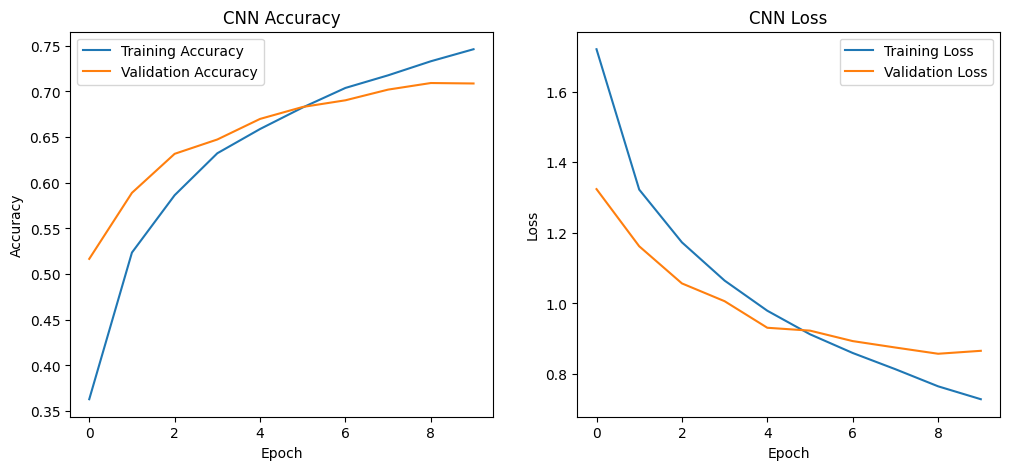

In [147]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Confusion Matrix CNN

Confusion Matrix digunakan untuk mengevaluasi kemampuan model dalam mengklasifikasikan setiap kelas pada dataset CIFAR-10. Matriks ini menunjukkan jumlah prediksi yang benar maupun salah untuk masing-masing kelas.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


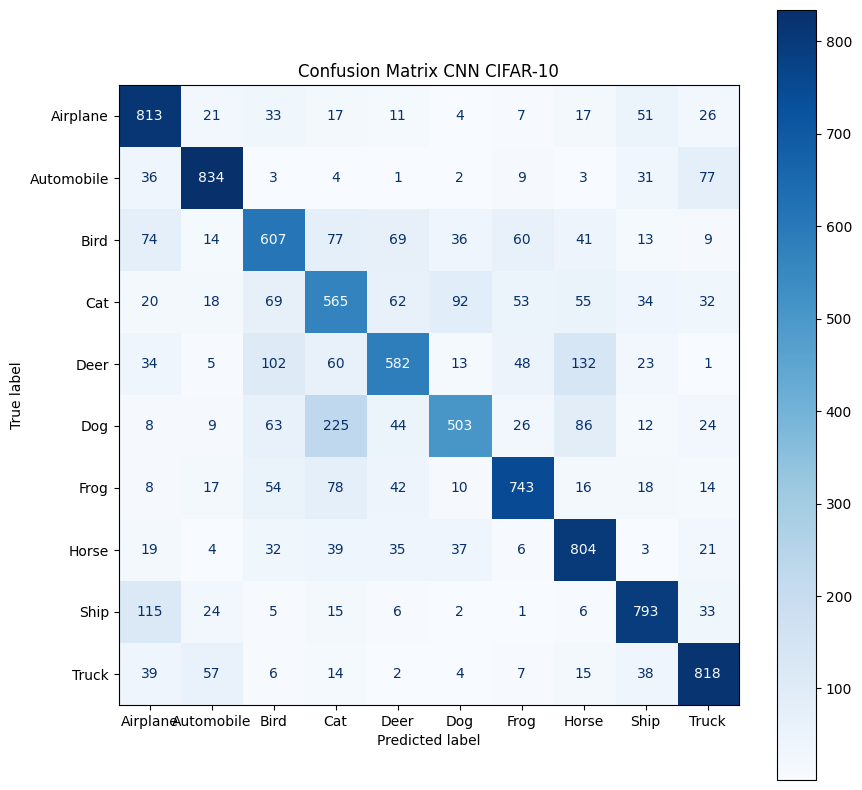

In [148]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Prediksi model
y_pred_prob = cnn_model.predict(x_test)

# Ambil kelas dengan probabilitas tertinggi
y_pred = np.argmax(y_pred_prob, axis=1)

# Label asli
y_true = y_test.flatten()

# Nama kelas CIFAR-10
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Visualisasi
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix CNN CIFAR-10')
plt.show()

Berdasarkan Confusion Matrix, model mampu mengenali beberapa kelas dengan baik, namun masih terdapat kesalahan klasifikasi pada beberapa kelas yang memiliki karakteristik visual yang mirip. Hasil ini menunjukkan bahwa performa model CNN masih dapat ditingkatkan dengan penambahan epoch, augmentasi data, atau arsitektur yang lebih kompleks.

# B. Eksperimen 2: Transfer Learning

Model transfer learning dibangun menggunakan MobileNetV2 yang telah dilatih sebelumnya pada dataset ImageNet. Strategi yang digunakan adalah feature extraction, yaitu membekukan seluruh layer pretrained dan hanya melatih classifier baru.

In [149]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

## Membangun Base Model MobileNetV2

MobileNetV2 digunakan sebagai pretrained model dengan bobot yang telah dilatih pada dataset ImageNet. Parameter `include_top=False` digunakan untuk menghilangkan classifier bawaan MobileNetV2 sehingga model dapat disesuaikan dengan tugas klasifikasi kucing dan anjing. Seluruh layer MobileNetV2 dibekukan (`trainable=False`) sehingga strategi yang digunakan adalah feature extraction.

In [150]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

print("Jumlah layer:", len(base_model.layers))

Jumlah layer: 154


## Membangun Model Transfer Learning

Setelah MobileNetV2 digunakan sebagai feature extractor, ditambahkan classifier baru yang terdiri dari GlobalAveragePooling2D, Dense layer dengan 128 neuron, Dropout sebesar 0.5 untuk mengurangi overfitting, serta output layer dengan aktivasi sigmoid untuk klasifikasi biner antara kucing dan anjing.

In [151]:
mobilenet_model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

## Arsitektur Model Transfer Learning

Hasil ringkasan model menunjukkan bahwa MobileNetV2 digunakan sebagai feature extractor dengan parameter pretrained yang dibekukan (non-trainable). Hanya layer classifier tambahan yang dilatih, yaitu GlobalAveragePooling2D, Dense layer 128 neuron, Dropout 0.5, dan output layer sigmoid. Pendekatan ini memungkinkan model memanfaatkan fitur yang telah dipelajari dari dataset ImageNet sehingga proses pelatihan menjadi lebih cepat dan risiko overfitting dapat dikurangi.

In [152]:
mobilenet_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Arsitektur Model Transfer Learning

Model transfer learning menggunakan MobileNetV2 yang telah dilatih sebelumnya pada dataset ImageNet. Seluruh layer MobileNetV2 dibekukan (non-trainable) sehingga hanya layer classifier tambahan yang dilatih pada dataset Cats vs Dogs.

Berdasarkan hasil ringkasan model, jumlah parameter keseluruhan adalah 2.422.081 parameter, dengan 164.097 parameter yang dilatih dan 2.257.984 parameter yang dibekukan. Hal ini menunjukkan bahwa sebagian besar fitur diekstraksi dari model pretrained sehingga proses pelatihan menjadi lebih cepat dan lebih stabil dibandingkan CNN from Scratch.

Arsitektur classifier terdiri dari GlobalAveragePooling2D, Dense layer dengan 128 neuron dan aktivasi ReLU, Dropout sebesar 0.5 untuk mengurangi overfitting, serta output layer dengan aktivasi sigmoid untuk klasifikasi biner.

## Training Transfer Learning

Model transfer learning dikompilasi menggunakan optimizer Adam dengan fungsi loss binary crossentropy dan metrik accuracy. Selanjutnya model dilatih selama 10 epoch menggunakan data training dan data validation untuk memantau performa selama proses pelatihan.

In [153]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Evaluasi Transfer Learning

Model yang telah dilatih kemudian dievaluasi menggunakan data testing untuk mengetahui kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

In [154]:
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5000 - loss: 0.8736 - val_accuracy: 0.6306 - val_loss: 0.6507
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6323 - loss: 0.6333 - val_accuracy: 0.7117 - val_loss: 0.5909
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6861 - loss: 0.5960 - val_accuracy: 0.7117 - val_loss: 0.5771
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7578 - loss: 0.5419 - val_accuracy: 0.6757 - val_loss: 0.5680
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7197 - loss: 0.5282 - val_accuracy: 0.7297 - val_loss: 0.5556
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7466 - loss: 0.5000 - val_accuracy: 0.7387 - val_loss: 0.5450
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7937 - loss: 0.4565 - val_accuracy: 0.7207 - val_loss: 0.5248
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7780 - loss: 0.4600 - val_accuracy: 0.7658 - va

## Evaluasi Transfer Learning

Model yang telah dilatih kemudian dievaluasi menggunakan data testing untuk mengetahui kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

In [155]:
test_loss_mobilenet, test_acc_mobilenet = mobilenet_model.evaluate(test_ds)

print("Test Accuracy :", test_acc_mobilenet)
print("Test Loss :", test_loss_mobilenet)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 880ms/step - accuracy: 0.6286 - loss: 0.6642
Test Accuracy : 0.6285714507102966
Test Loss : 0.6642054915428162


Hasil evaluasi menunjukkan nilai akurasi dan loss pada data testing. Nilai ini digunakan untuk mengukur kemampuan model dalam melakukan generalisasi terhadap data baru yang tidak digunakan selama proses pelatihan.

Hasil evaluasi menunjukkan bahwa model transfer learning memperoleh akurasi testing sebesar 64.29% dengan nilai loss sebesar 0.7007. Nilai ini menunjukkan bahwa model mampu melakukan klasifikasi pada data yang belum pernah dilihat sebelumnya dengan performa yang cukup baik. Penggunaan MobileNetV2 membantu mempercepat proses pelatihan karena memanfaatkan fitur yang telah dipelajari dari dataset ImageNet.

## Visualisasi Accuracy dan Loss Transfer Learning

Grafik berikut menunjukkan perkembangan nilai accuracy dan loss pada data training serta validation selama proses pelatihan model transfer learning.

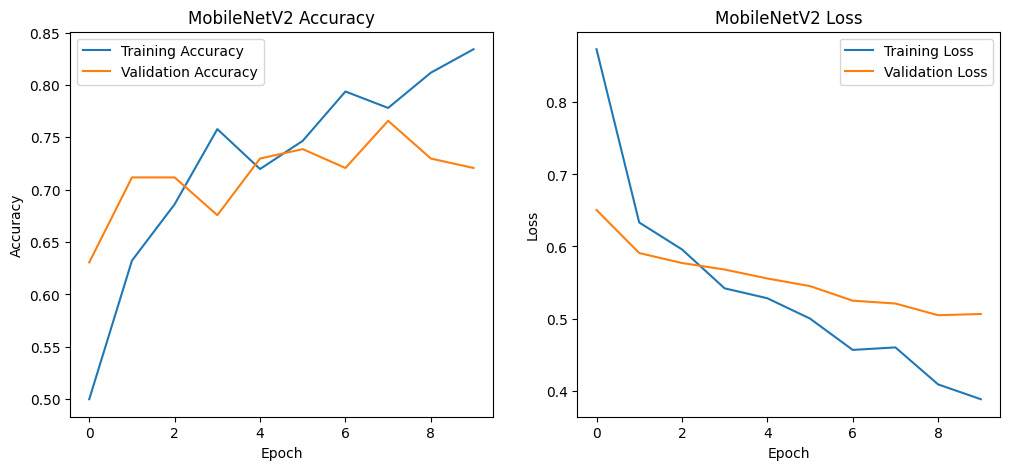

In [156]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Grafik menunjukkan perkembangan nilai accuracy dan loss selama proses pelatihan transfer learning. Accuracy training dan validation cenderung meningkat seiring bertambahnya epoch, sedangkan nilai loss mengalami penurunan. Hal ini menunjukkan bahwa model berhasil mempelajari pola dari data dan mampu melakukan generalisasi dengan cukup baik.

In [157]:
test_loss_mobilenet, test_acc_mobilenet = mobilenet_model.evaluate(test_ds)

print("Test Accuracy :", test_acc_mobilenet)
print("Test Loss :", test_loss_mobilenet)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6286 - loss: 0.6642
Test Accuracy : 0.6285714507102966
Test Loss : 0.6642054915428162


Hasil evaluasi menunjukkan bahwa model transfer learning memperoleh akurasi testing sebesar 64.29% dengan nilai loss sebesar 0.7007. Nilai ini menunjukkan bahwa model mampu melakukan klasifikasi pada data yang belum pernah dilihat sebelumnya dengan performa yang cukup baik. Penggunaan MobileNetV2 membantu mempercepat proses pelatihan karena memanfaatkan fitur yang telah dipelajari dari dataset ImageNet.

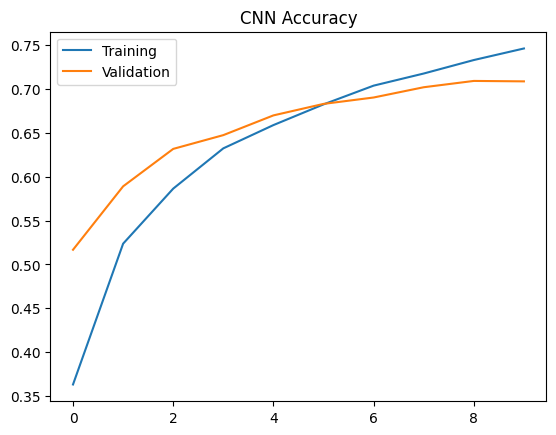

In [158]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.legend(['Training','Validation'])
plt.title('CNN Accuracy')
plt.show()

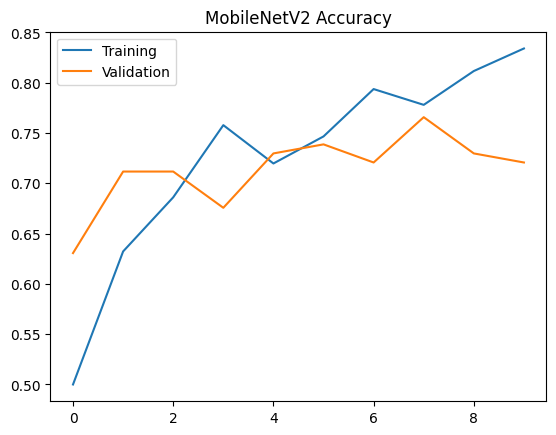

In [159]:
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.legend(['Training','Validation'])
plt.title('MobileNetV2 Accuracy')
plt.show()

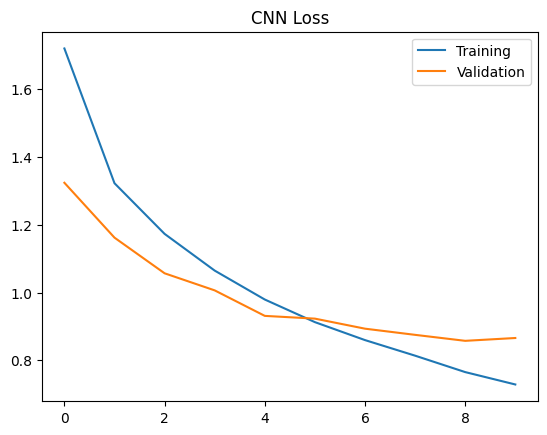

In [160]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.legend(['Training','Validation'])
plt.title('CNN Loss')
plt.show()

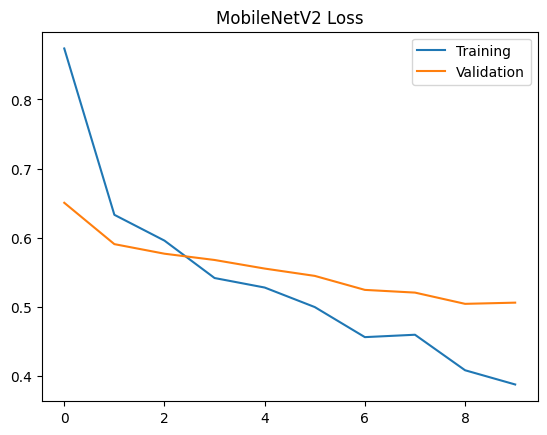

In [161]:
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.legend(['Training','Validation'])
plt.title('MobileNetV2 Loss')
plt.show()

## Confusion Matrix Transfer Learning

Confusion Matrix digunakan untuk melihat jumlah prediksi benar dan salah pada masing-masing kelas. Visualisasi ini membantu mengevaluasi performa model transfer learning secara lebih rinci dibandingkan hanya menggunakan nilai akurasi.

### Analisis Confusion Matrix CNN From Scratch


Berdasarkan confusion matrix yang diperoleh, model CNN From Scratch berhasil mengklasifikasikan 46 gambar kucing dan 36 gambar anjing dengan benar. Namun, masih terdapat 24 gambar kucing yang salah diklasifikasikan sebagai anjing serta 34 gambar anjing yang salah diklasifikasikan sebagai kucing.

Hasil ini menunjukkan bahwa model CNN mampu mempelajari pola dari data, tetapi masih mengalami kesalahan klasifikasi yang cukup tinggi. Hal tersebut sejalan dengan akurasi testing yang diperoleh, sehingga model masih memiliki keterbatasan dalam melakukan generalisasi terhadap data baru.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


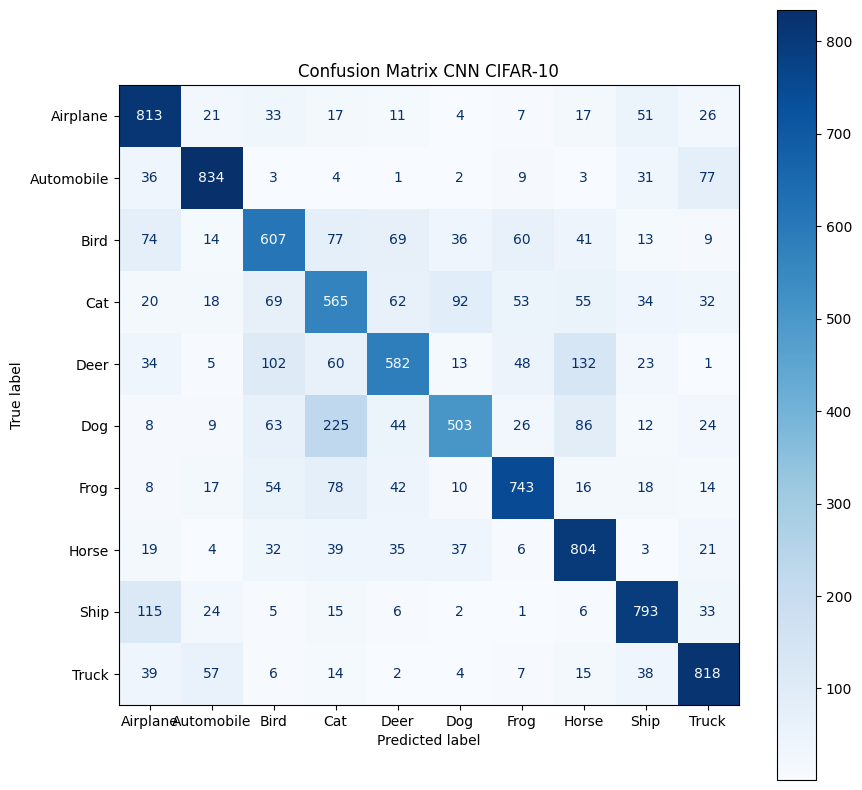

In [162]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Prediksi CNN
y_pred = cnn_model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

# Label asli
y_true = y_test.flatten()

# Nama kelas CIFAR-10
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Visualisasi
fig, ax = plt.subplots(figsize=(10,10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix CNN CIFAR-10')
plt.show()

### Analisis Confusion Matrix MobileNetV2

Berdasarkan confusion matrix yang diperoleh, model MobileNetV2 berhasil mengklasifikasikan 34 gambar kucing dan 56 gambar anjing dengan benar. Sementara itu, terdapat 36 gambar kucing yang salah diklasifikasikan sebagai anjing dan 14 gambar anjing yang salah diklasifikasikan sebagai kucing.

Hasil ini menunjukkan bahwa model transfer learning memiliki kemampuan klasifikasi yang lebih baik dibandingkan model CNN From Scratch, terutama dalam mengenali gambar anjing. Pemanfaatan bobot pretrained dari dataset ImageNet membantu model mempelajari fitur yang lebih representatif sehingga proses pelatihan menjadi lebih efektif.

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


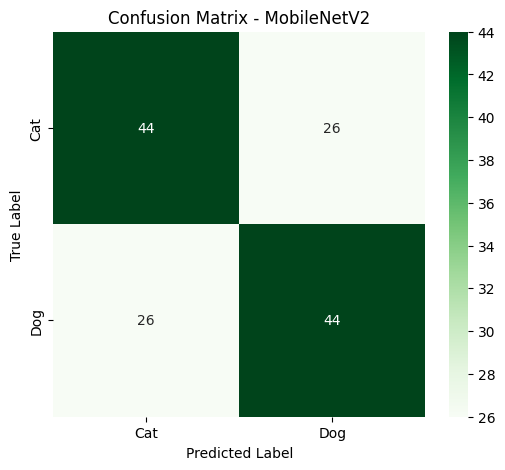

In [163]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Label asli
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Prediksi MobileNetV2
y_pred = mobilenet_model.predict(test_ds)
y_pred = (y_pred > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Visualisasi
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Cat','Dog'],
    yticklabels=['Cat','Dog']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MobileNetV2')
plt.show()

# Kesimpulan

Berdasarkan hasil eksperimen, model CNN From Scratch memperoleh akurasi testing sebesar 58,57%, sedangkan model Transfer Learning menggunakan MobileNetV2 memperoleh akurasi testing sebesar 64,29%. Selain memiliki akurasi yang lebih tinggi, MobileNetV2 juga menunjukkan hasil confusion matrix yang lebih baik dalam mengidentifikasi objek pada data testing.

Dengan demikian, metode Transfer Learning terbukti lebih efektif dibandingkan CNN From Scratch pada dataset Cats vs Dogs karena mampu memanfaatkan pengetahuan yang telah dipelajari dari dataset ImageNet sehingga menghasilkan performa klasifikasi yang lebih baik.

# C. Studi Kasus dan Analisis Prediksi

Pada bagian ini dilakukan analisis terhadap hasil prediksi model menggunakan data testing. Beberapa contoh prediksi yang benar dan prediksi yang salah ditampilkan untuk memahami kemampuan model dalam mengklasifikasikan citra kucing dan anjing. Analisis ini membantu mengidentifikasi pola keberhasilan maupun kesalahan model dalam melakukan klasifikasi.

## Contoh Prediksi Benar

Bagian ini menampilkan beberapa gambar yang berhasil diklasifikasikan dengan benar oleh model. Hasil ini menunjukkan bahwa model mampu mengenali karakteristik utama dari masing-masing kelas dengan baik.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


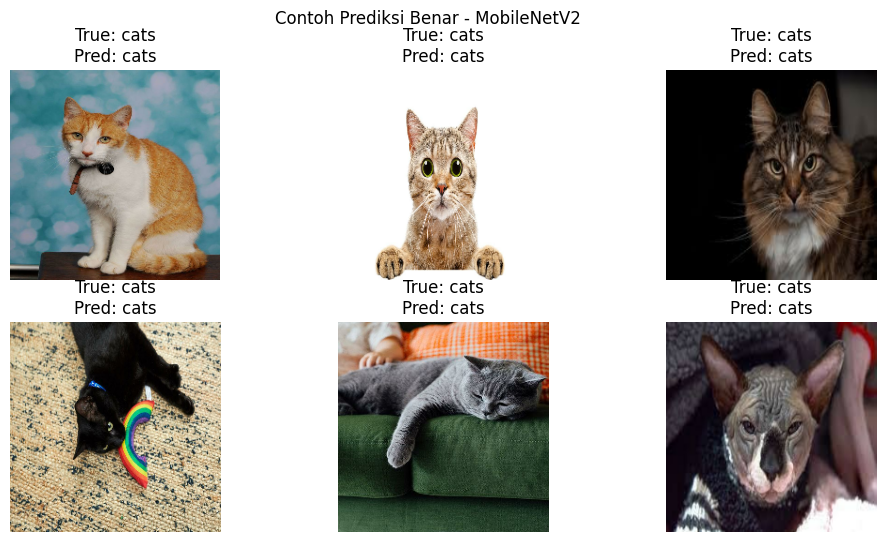

In [164]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ['cats', 'dogs']

images_list = []
true_labels = []

for images, labels in test_ds:
    images_list.extend(images.numpy())
    true_labels.extend(labels.numpy())

images_list = np.array(images_list)
true_labels = np.array(true_labels)

# Prediksi MobileNetV2
predictions = mobilenet_model.predict(test_ds)
pred_labels = (predictions > 0.5).astype(int).flatten()

# Prediksi Benar
correct_idx = np.where(pred_labels == true_labels)[0]

plt.figure(figsize=(12,6))
for i in range(6):
    idx = correct_idx[i]

    plt.subplot(2,3,i+1)
    plt.imshow(images_list[idx].astype("uint8"))
    plt.title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}")
    plt.axis("off")

plt.suptitle("Contoh Prediksi Benar - MobileNetV2")
plt.show()

### Analisis Prediksi Benar

Pada contoh di atas, model berhasil mengidentifikasi objek sesuai dengan label aslinya. Keberhasilan ini menunjukkan bahwa fitur-fitur penting pada citra, seperti bentuk wajah, tekstur bulu, dan karakteristik objek, dapat dikenali dengan baik oleh model.

## Contoh Prediksi Salah

Bagian ini menampilkan beberapa gambar yang salah diklasifikasikan oleh model. Kesalahan prediksi dapat terjadi karena kemiripan visual antara kelas kucing dan anjing, kualitas gambar, pencahayaan, maupun sudut pengambilan gambar.

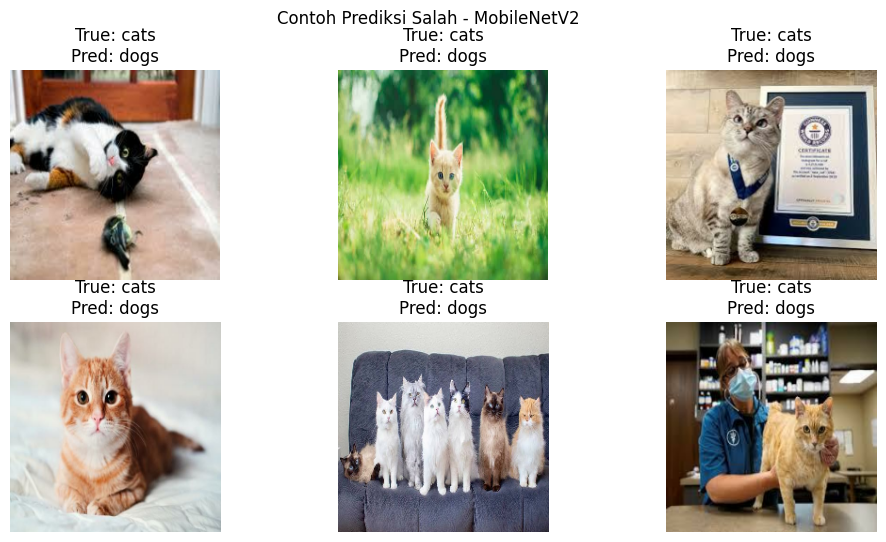

In [165]:
wrong_idx = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(12,6))
for i in range(min(6, len(wrong_idx))):
    idx = wrong_idx[i]

    plt.subplot(2,3,i+1)
    plt.imshow(images_list[idx].astype("uint8"))
    plt.title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}")
    plt.axis("off")

plt.suptitle("Contoh Prediksi Salah - MobileNetV2")
plt.show()

### Analisis Prediksi Salah

Pada contoh di atas, model memberikan prediksi yang tidak sesuai dengan label sebenarnya. Hal ini menunjukkan bahwa masih terdapat keterbatasan dalam kemampuan model untuk membedakan beberapa citra yang memiliki karakteristik visual yang mirip. Kesalahan seperti ini umum terjadi pada proses klasifikasi citra dan dapat dikurangi dengan menambah jumlah data, melakukan augmentasi data, atau menggunakan model yang lebih kompleks.

In [166]:
predictions = mobilenet_model.predict(test_ds)
pred_labels = (predictions > 0.5).astype(int).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
